Running benchmarks... this might take a few seconds.


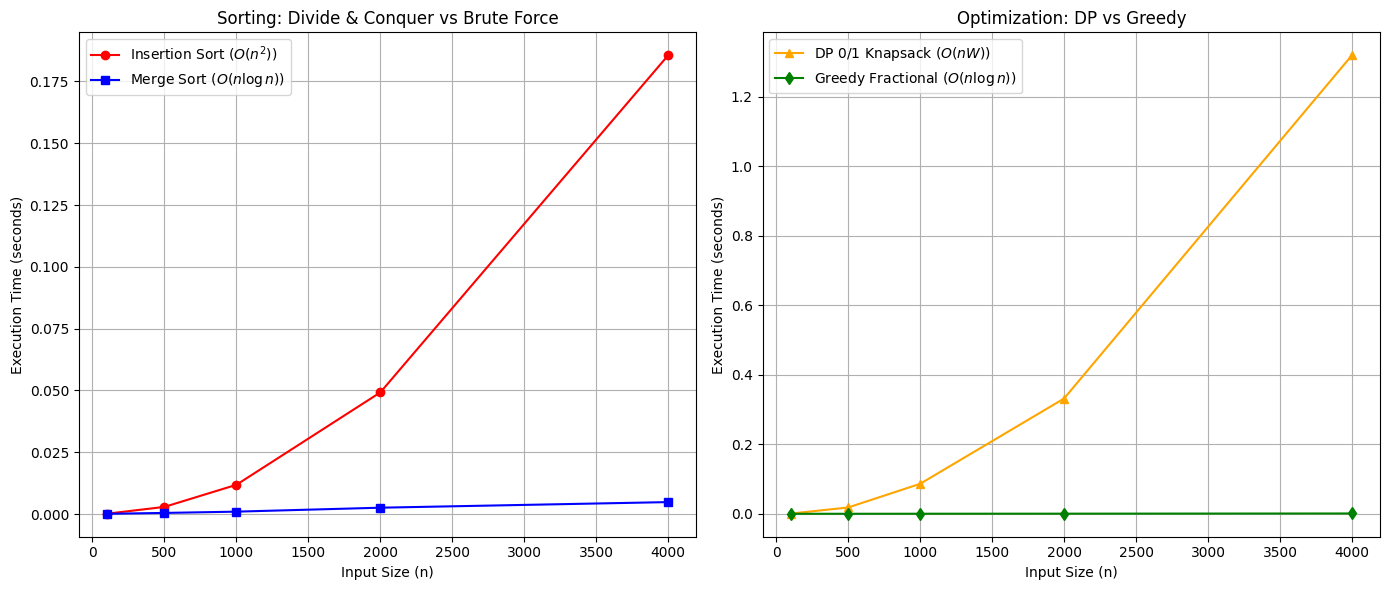

In [2]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np

# 1. DIVIDE AND CONQUER (Merge Sort)
def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        L = arr[:mid]
        R = arr[mid:]

        merge_sort(L)
        merge_sort(R)

        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]
                i += 1
            else:
                arr[k] = R[j]
                j += 1
            k += 1

        while i < len(L):
            arr[k] = L[i]
            i += 1
            k += 1

        while j < len(R):
            arr[k] = R[j]
            j += 1
            k += 1

# 2. BRUTE FORCE SORTING (For Comparison)
def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and key < arr[j]:
            arr[j + 1] = arr[j]
            j -= 1
        arr[j + 1] = key

# 3. GREEDY (Fractional Knapsack)
def fractional_knapsack(values, weights, capacity):
    items = sorted(list(zip(values, weights)), key=lambda x: x[0]/x[1], reverse=True)
    total_value = 0
    for v, w in items:
        if capacity >= w:
            capacity -= w
            total_value += v
        else:
            total_value += v * (capacity / w)
            break
    return total_value

# 4. DYNAMIC PROGRAMMING (0/1 Knapsack)
def dp_knapsack(W, wt, val, n):
    K = [[0 for x in range(W + 1)] for x in range(n + 1)]
    for i in range(n + 1):
        for w in range(W + 1):
            if i == 0 or w == 0:
                K[i][w] = 0
            elif wt[i-1] <= w:
                K[i][w] = max(val[i-1] + K[i-1][w-wt[i-1]], K[i-1][w])
            else:
                K[i][w] = K[i-1][w]
    return K[n][W]

# PROFILING & VISUALIZATION ENGINE
def profile_algorithms():
    input_sizes = [100, 500, 1000, 2000, 4000]
    merge_times = []
    insert_times = []
    greedy_times = []
    dp_times = []

    print("Running benchmarks... this might take a few seconds.")

    for n in input_sizes:
        # Generate random data
        arr = [random.randint(1, 10000) for _ in range(n)]
        values = [random.randint(10, 100) for _ in range(n)]
        weights = [random.randint(1, 50) for _ in range(n)]
        capacity = n * 5
        
        # Test Merge Sort
        arr_copy = arr.copy()
        start = time.perf_counter()
        merge_sort(arr_copy)
        merge_times.append(time.perf_counter() - start)
        
        # Test Insertion Sort
        arr_copy = arr.copy()
        start = time.perf_counter()
        insertion_sort(arr_copy)
        insert_times.append(time.perf_counter() - start)

        # Test Greedy Knapsack
        start = time.perf_counter()
        fractional_knapsack(values, weights, capacity)
        greedy_times.append(time.perf_counter() - start)

        # Test DP Knapsack
        start = time.perf_counter()
        dp_knapsack(capacity // 10, weights, values, n)
        dp_times.append(time.perf_counter() - start)

    # PLOTTING
    plt.figure(figsize=(14, 6))

    # Plot 1: Sorting Comparison
    plt.subplot(1, 2, 1)
    plt.plot(input_sizes, insert_times, label='Insertion Sort ($O(n^2)$)', marker='o', color='red')
    plt.plot(input_sizes, merge_times, label=r'Merge Sort ($O(n \log n)$)', marker='s', color='blue')
    plt.title("Sorting: Divide & Conquer vs Brute Force")
    plt.xlabel("Input Size (n)")
    plt.ylabel("Execution Time (seconds)")
    plt.grid(True)
    plt.legend()

    # Plot 2: Greedy vs DP
    plt.subplot(1, 2, 2)
    plt.plot(input_sizes, dp_times, label='DP 0/1 Knapsack ($O(nW)$)', marker='^', color='orange')
    plt.plot(input_sizes, greedy_times, label=r'Greedy Fractional ($O(n \log n)$)', marker='d', color='green')
    plt.title("Optimization: DP vs Greedy")
    plt.xlabel("Input Size (n)")
    plt.ylabel("Execution Time (seconds)")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the engine
profile_algorithms()